# 🔍 Industrial Surface Defect Detection
### *Feature-Based Anomaly Detection (PatchCore-style)*

**Idea:** Train ONLY on normal images (unsupervised — no defect samples needed). Learn "what normal looks like", then flag anything that deviates from it as a defect.

**Pipeline:**
> Image → Feature extraction (backbone) → **Memory Bank** (coreset) → k-NN distance → **decision threshold** → OK/NG + **heatmap** localizing the defect

**Dataset:** MVTec-AD (15 categories) · **Backbones:** ResNet50 / DINO-ViT / DINOv2

---

## ⚙️ 0. Configuration & Imports (Setup)
Load libraries and initialize `Config`: device (GPU/CPU), dataset, scoring method, and threshold policy (`μ+2σ`).

In [1]:
!pip install -q torchvision

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, f1_score

from anomaly_system import Config, ImageTransform, ResNetFeatureExtractor, MemoryBank, AnomalyDetector, image_anomaly_score, smooth_score_map, compute_threshold

config = Config()
print(f"Device: {config.device}")
print(f"Dataset: {config.dataset_name}")
print(f"Scoring: method={config.score_method}, top_k={config.score_top_k}, smooth_sigma={config.smooth_sigma}")
print(f"Threshold: method={config.threshold_method}, param={config.threshold_param}")
print(f"Base path: {config.base_path.absolute()}")


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\ADMIN\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


C:\Users\ADMIN\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Dataset: toothbrush
Scoring: method=max, top_k=10, smooth_sigma=1.0
Threshold: method=sigma, param=2.0
Base path: C:\Users\ADMIN\Desktop\Test\mvtec_anomaly_detection


---
## 🖼️ 1. Image Preprocessing
Resize → ToTensor → ImageNet normalization (mean/std). Create the output folder.

In [2]:
image_transform = ImageTransform(image_size=config.image_size)
print(f"Image transform ready: {config.image_size}x{config.image_size}")

Image transform ready: 224x224


In [3]:
# Create output folder
output_root = Path('outputs')
output_root.mkdir(parents=True, exist_ok=True)
print(f"Output folder: {output_root.absolute()}")

Output folder: C:\Users\ADMIN\Desktop\Test\outputs


---
## 🧠 2. Build the Memory Bank (learn from normal images only)
Split `train/good` **80/20**:
- **80%** → build the Memory Bank (features are **L2-normalized**, then reduced with a **k-center greedy coreset** keeping ~10% representative points).
- **20%** → held out to calibrate the threshold in Section 3 → **prevents data leakage**.

In [4]:
backbone = ResNetFeatureExtractor(device=config.device)

train_good_dir = config.base_path / config.dataset_name / 'train' / 'good'
all_train_files = sorted(train_good_dir.glob('*.png'))

split_index = int(len(all_train_files) * 0.8)
build_files = all_train_files[:split_index]
calibration_files = all_train_files[split_index:]

memory_bank_features = []
for pth in tqdm(build_files, desc="Building memory bank (80% of train/good)", leave=False):
    image_tensor = image_transform(pth).to(config.device).unsqueeze(0)
    with torch.no_grad():
        features = backbone(image_tensor)
    memory_bank_features.append(features.cpu().detach())

print(f"Build set: {len(build_files)} images")
print(f"Calibration set (held-out good): {len(calibration_files)} images")
print(f"Feature shape per sample: {memory_bank_features[0].shape}")

memory_bank_manager = MemoryBank(device=config.device)
memory_bank_manager.build(memory_bank_features)
print(f"Memory bank size before selection: {memory_bank_manager.size}")

Building memory bank (80% of train/good):   0%|          | 0/48 [00:00<?, ?it/s]

Building memory bank (80% of train/good):   2%|▏         | 1/48 [00:00<00:23,  2.01it/s]

Building memory bank (80% of train/good):   8%|▊         | 4/48 [00:00<00:05,  7.57it/s]

Building memory bank (80% of train/good):  15%|█▍        | 7/48 [00:00<00:03, 11.76it/s]

Building memory bank (80% of train/good):  21%|██        | 10/48 [00:00<00:02, 14.71it/s]

...

Building memory bank (80% of train/good):  83%|████████▎ | 40/48 [00:02<00:00, 20.40it/s]

Building memory bank (80% of train/good):  90%|████████▉ | 43/48 [00:02<00:00, 20.79it/s]

Building memory bank (80% of train/good):  96%|█████████▌| 46/48 [00:02<00:00, 21.19it/s]

Build set: 48 images
Calibration set (held-out good): 12 images
Feature shape per sample: torch.Size([784, 1536])


Memory bank size before selection: 37632


In [5]:
memory_bank_manager.k_center_greedy_select(ratio=config.coreset_ratio)
print(f"Memory bank size after K-center greedy: {memory_bank_manager.size}")
print(f"Reduction: {memory_bank_features[0].shape[0]} → {memory_bank_manager.size} (10% representative samples)")

Memory bank size after K-center greedy: 3763
Reduction: 784 → 3763 (10% representative samples)


---
## 📏 3. Calibrate the Decision Threshold (leakage-free)
Score the **held-out good** set (images the Memory Bank has NEVER seen), then set the threshold with the `μ + 2σ` policy (~2.3% expected false-positive rate).

⚠️ **Never** use test labels to choose the threshold — that is data leakage. (See `tune_threshold.py` to analyze other threshold policies.)

In [6]:
y_score_calibration = []

for pth in tqdm(calibration_files, desc="Scoring held-out good images (calibration)", leave=False):
    image_tensor = image_transform(pth).to(config.device).unsqueeze(0)
    with torch.no_grad():
        features = backbone(image_tensor)
        features_normalized = features / (torch.norm(features, dim=1, keepdim=True) + 1e-8)
    distances = torch.cdist(features_normalized, memory_bank_manager.get(), p=2.0)
    patch_min = torch.min(distances, dim=1)[0]
    anomaly_score = image_anomaly_score(patch_min, method=config.score_method, top_k=config.score_top_k, smooth_sigma=config.smooth_sigma)
    y_score_calibration.append(anomaly_score.item())

print(f"Calibration scores (held-out good, NOT in memory bank):")
print(f"  Mean: {np.mean(y_score_calibration):.4f}")
print(f"  Std: {np.std(y_score_calibration):.4f}")

Scoring held-out good images (calibration):   0%|          | 0/12 [00:00<?, ?it/s]

Scoring held-out good images (calibration):   8%|▊         | 1/12 [00:00<00:01,  7.55it/s]

Scoring held-out good images (calibration):  25%|██▌       | 3/12 [00:00<00:00, 13.26it/s]

Scoring held-out good images (calibration):  42%|████▏     | 5/12 [00:00<00:00, 15.46it/s]

Scoring held-out good images (calibration):  58%|█████▊    | 7/12 [00:00<00:00, 16.09it/s]

Scoring held-out good images (calibration):  75%|███████▌  | 9/12 [00:00<00:00, 16.74it/s]

Scoring held-out good images (calibration):  92%|█████████▏| 11/12 [00:00<00:00, 16.80it/s]

Calibration scores (held-out good, NOT in memory bank):
  Mean: 0.2790
  Std: 0.0118


In [7]:
print(f"Calibration (held-out good) score statistics:")
print(f"Min: {np.min(y_score_calibration):.4f}")
print(f"Max: {np.max(y_score_calibration):.4f}")
print(f"Mean: {np.mean(y_score_calibration):.4f}")
print(f"Median: {np.median(y_score_calibration):.4f}")

Calibration (held-out good) score statistics:
Min: 0.2582
Max: 0.2980
Mean: 0.2790
Median: 0.2770


Decision threshold from held-out good calibration set:
  Mean: 0.2790
  Std: 0.0118
  Policy: sigma (param=2.0)
  Threshold: 0.3025


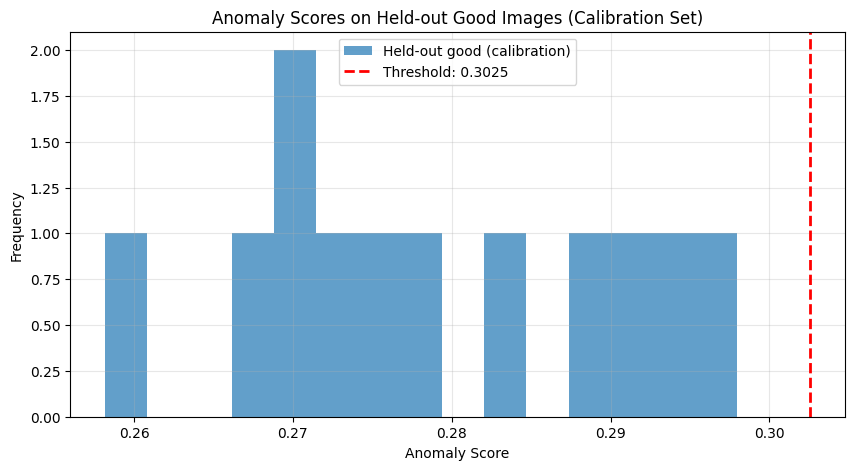

In [8]:
mean_calib_score = np.mean(y_score_calibration)
std_calib_score = np.std(y_score_calibration)

# Leakage-free operating point: set threshold from held-out good ONLY (never test labels).
# Default config policy = mean + 2*std (~2.3% expected FPR), robust on small calibration sets.
decision_threshold = compute_threshold(y_score_calibration,
                                       method=config.threshold_method,
                                       param=config.threshold_param)

print(f"Decision threshold from held-out good calibration set:")
print(f"  Mean: {mean_calib_score:.4f}")
print(f"  Std: {std_calib_score:.4f}")
print(f"  Policy: {config.threshold_method} (param={config.threshold_param})")
print(f"  Threshold: {decision_threshold:.4f}")

plt.figure(figsize=(10, 5))
plt.hist(y_score_calibration, bins=15, alpha=0.7, label='Held-out good (calibration)')
plt.axvline(decision_threshold, color='r', linestyle='--', linewidth=2, label=f'Threshold: {decision_threshold:.4f}')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')
plt.title('Anomaly Scores on Held-out Good Images (Calibration Set)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## 🧪 4. Evaluate on the Test Set
Score every test image. MVTec label convention: the `good` folder → label **0** (normal); every other defect folder → label **1** (anomalous).

In [9]:
y_score_test = []
y_true_test = []

test_root = config.base_path / config.dataset_name / 'test'
test_subfolders = sorted([d for d in test_root.iterdir() if d.is_dir()])

for folder_path_test in test_subfolders:
    class_label = folder_path_test.name
    label = 0 if class_label == 'good' else 1
    for pth in tqdm(sorted(folder_path_test.glob('*.png')), desc=f"Testing on {class_label}", leave=False):
        image_tensor = image_transform(pth).to(config.device).unsqueeze(0)
        with torch.no_grad():
            features = backbone(image_tensor)
            features_normalized = features / (torch.norm(features, dim=1, keepdim=True) + 1e-8)
        distances = torch.cdist(features_normalized, memory_bank_manager.get(), p=2.0)
        patch_min = torch.min(distances, dim=1)[0]
        anomaly_score = image_anomaly_score(patch_min, method=config.score_method, top_k=config.score_top_k, smooth_sigma=config.smooth_sigma)
        y_score_test.append(anomaly_score.item())
        y_true_test.append(label)

y_score_test = np.array(y_score_test)
y_true_test = np.array(y_true_test)

defect_types = [d.name for d in test_subfolders if d.name != 'good']
print(f"Test set size: {len(y_score_test)}")
print(f"  Good samples: {np.sum(y_true_test == 0)}")
print(f"  Defective samples: {np.sum(y_true_test == 1)}")
print(f"  Defect types: {defect_types}")

Testing on defective:   0%|          | 0/30 [00:00<?, ?it/s]

Testing on defective:   7%|▋         | 2/30 [00:00<00:01, 17.12it/s]

Testing on defective:  13%|█▎        | 4/30 [00:00<00:01, 17.63it/s]

Testing on defective:  20%|██        | 6/30 [00:00<00:01, 17.97it/s]

Testing on defective:  27%|██▋       | 8/30 [00:00<00:01, 17.95it/s]

...

Testing on good:  50%|█████     | 6/12 [00:00<00:00, 18.38it/s]

Testing on good:  67%|██████▋   | 8/12 [00:00<00:00, 17.91it/s]

Testing on good:  83%|████████▎ | 10/12 [00:00<00:00, 17.61it/s]

Testing on good: 100%|██████████| 12/12 [00:00<00:00, 17.64it/s]

Test set size: 42
  Good samples: 12
  Defective samples: 30
  Defect types: ['defective']


In [10]:
print(f"Sample test scores (indices 40-45):")
print(f"Scores: {y_score_test[40:45]}")
print(f"Labels: {y_true_test[40:45]} (0=good, 1=defective)")

Sample test scores (indices 40-45):
Scores: [0.2873812  0.31755468]
Labels: [0 0] (0=good, 1=defective)


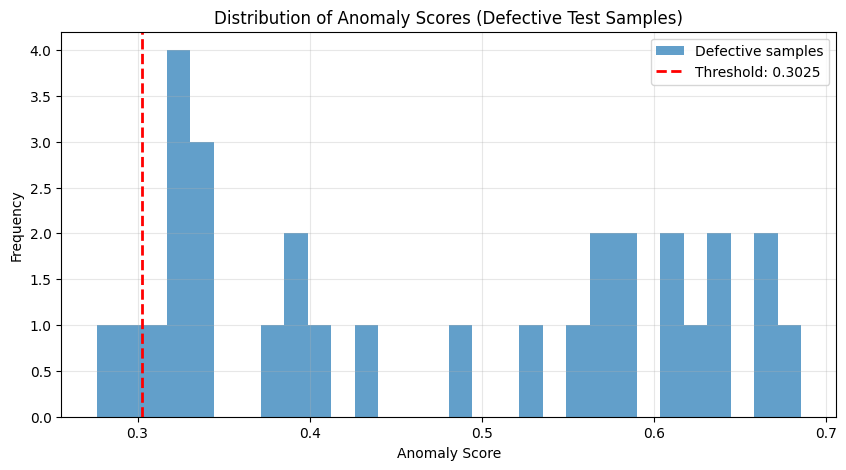

In [11]:
y_score_defective = y_score_test[y_true_test == 1]

plt.figure(figsize=(10, 5))
plt.hist(y_score_defective, bins=30, alpha=0.7, label='Defective samples')
plt.axvline(decision_threshold, color='r', linestyle='--', linewidth=2, label=f'Threshold: {decision_threshold:.4f}')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')
plt.title('Distribution of Anomaly Scores (Defective Test Samples)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## 🎨 5. Visualize Defect Localization (Heatmap)
Show the (Gaussian-smoothed) anomaly heatmap + the defect region overlaid on a defective image. Uses an **absolute color scale** and a **real-threshold** overlay so the colors reflect the true anomaly level.

Testing on: defective/000.png


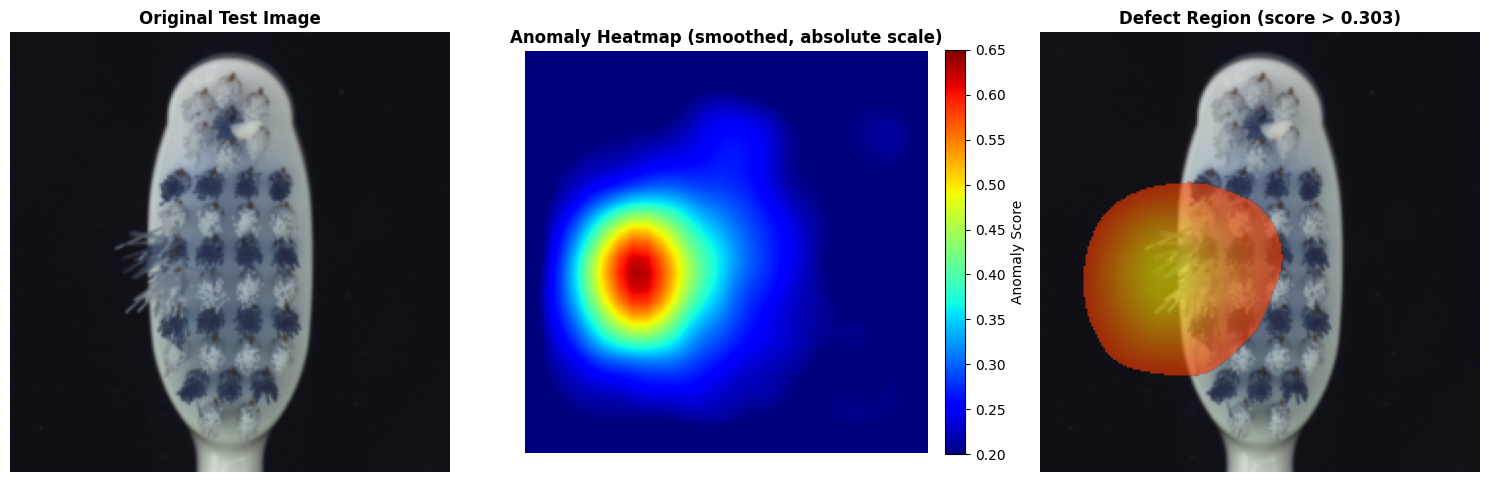

In [12]:
test_root = config.base_path / config.dataset_name / 'test'
defect_folders = sorted([d for d in test_root.iterdir() if d.is_dir() and d.name != 'good'])
test_image_path = sorted(defect_folders[0].glob('*.png'))[0]

print(f"Testing on: {defect_folders[0].name}/{test_image_path.name}")

test_image_tensor = image_transform(test_image_path).to(config.device).unsqueeze(0)

with torch.no_grad():
    features = backbone(test_image_tensor)
    features_normalized = features / (torch.norm(features, dim=1, keepdim=True) + 1e-8)

distances = torch.cdist(features_normalized, memory_bank_manager.get(), p=2.0)
dist_score = torch.min(distances, dim=1)[0]
side = int(round(dist_score.numel() ** 0.5))
segm_map = smooth_score_map(dist_score.view(side, side), config.smooth_sigma).view(1, 1, side, side)

segm_map_upscaled = torch.nn.functional.interpolate(
    segm_map,
    size=(224, 224),
    mode='bilinear'
).cpu().squeeze().numpy()

score_min, score_max = 0.20, 0.65
imagenet_mean = np.array([0.485, 0.456, 0.406])
imagenet_std = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

original_image = test_image_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
original_image = np.clip(original_image * imagenet_std + imagenet_mean, 0, 1)
axes[0].imshow(original_image)
axes[0].set_title('Original Test Image', fontsize=12, fontweight='bold')
axes[0].axis('off')

im1 = axes[1].imshow(segm_map_upscaled, cmap='jet', vmin=score_min, vmax=score_max)
axes[1].set_title('Anomaly Heatmap (smoothed, absolute scale)', fontsize=12, fontweight='bold')
axes[1].axis('off')
cbar1 = plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
cbar1.set_label('Anomaly Score', fontsize=10)

defect_mask = np.ma.masked_where(segm_map_upscaled <= decision_threshold, segm_map_upscaled)
axes[2].imshow(original_image)
axes[2].imshow(defect_mask, cmap='autumn', alpha=0.6, vmin=score_min, vmax=score_max)
axes[2].set_title(f'Defect Region (score > {decision_threshold:.3f})', fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

---
## 📊 6. Quantitative Metrics (AUC, F1, Confusion Matrix)
- **AUC-ROC**: good/defect ranking quality — **threshold-independent** (primary metric).
- **F1 + Confusion Matrix**: decision quality at the `μ+2σ` threshold.


Evaluation Results (threshold calibrated on held-out good):
  AUC-ROC: 0.9444
  F1-Score: 0.9355


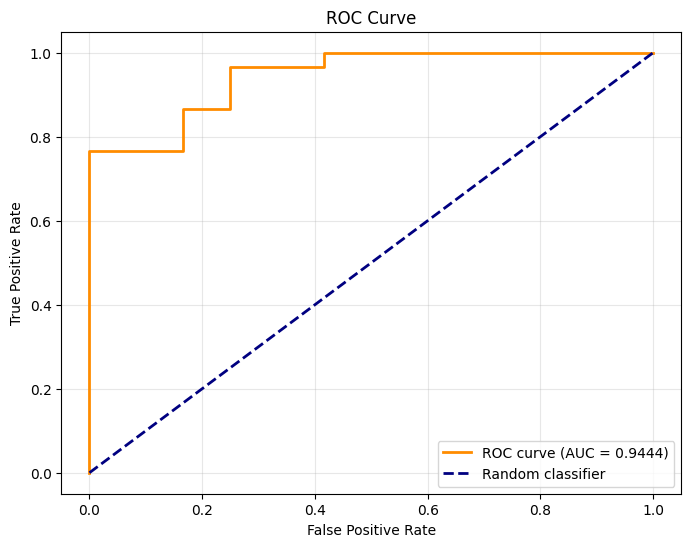

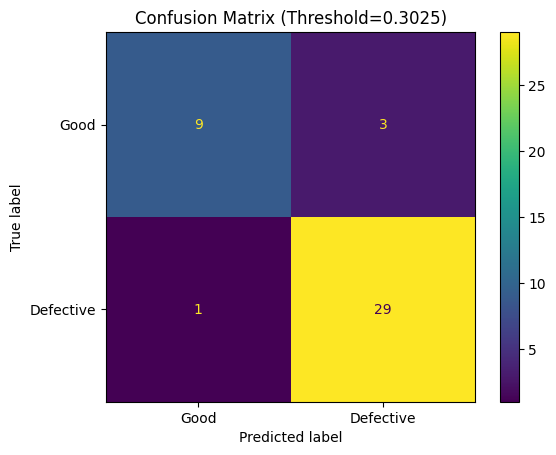

In [13]:
y_pred_test = (y_score_test >= decision_threshold).astype(int)

auc_roc_score = roc_auc_score(y_true_test, y_score_test)
f1_test = f1_score(y_true_test, y_pred_test)

fpr, tpr, thresholds = roc_curve(y_true_test, y_score_test)

print(f"\nEvaluation Results (threshold calibrated on held-out good):")
print(f"  AUC-ROC: {auc_roc_score:.4f}")
print(f"  F1-Score: {f1_test:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_roc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

cm = confusion_matrix(y_true_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Good', 'Defective'])
disp.plot()
plt.title(f"Confusion Matrix (Threshold={decision_threshold:.4f})")
plt.show()

---
## 🖼️ 7. Qualitative Comparison: Good vs Defect
Run on a few **good** and **defective** images side by side — check that predictions + heatmaps localize the defect correctly, and that good images are not falsely flagged.

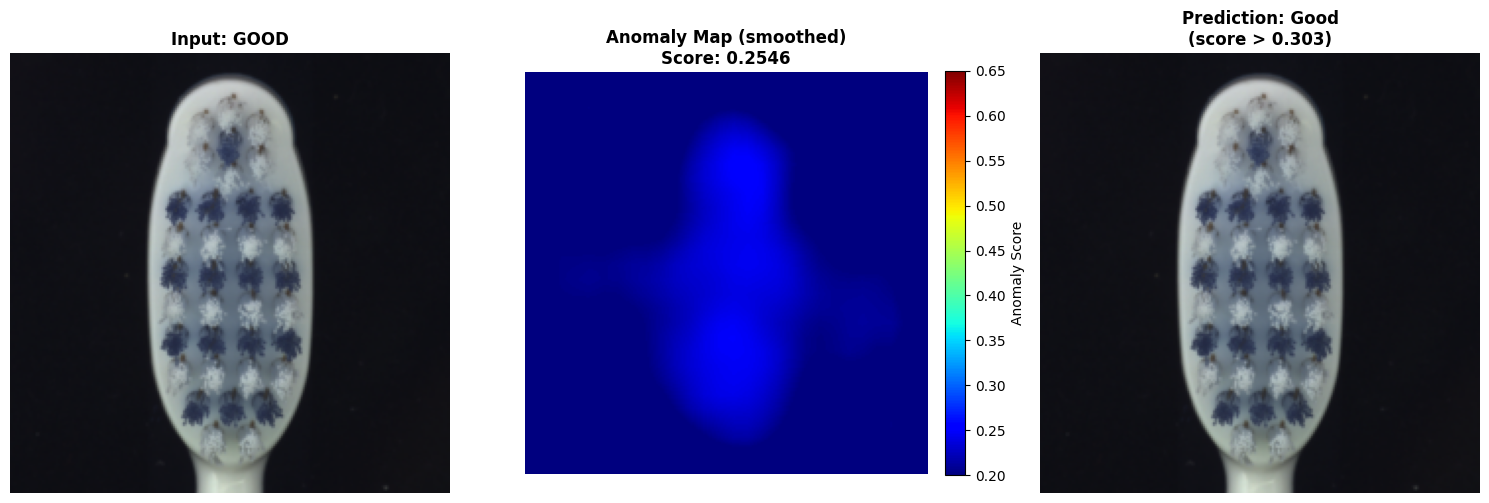

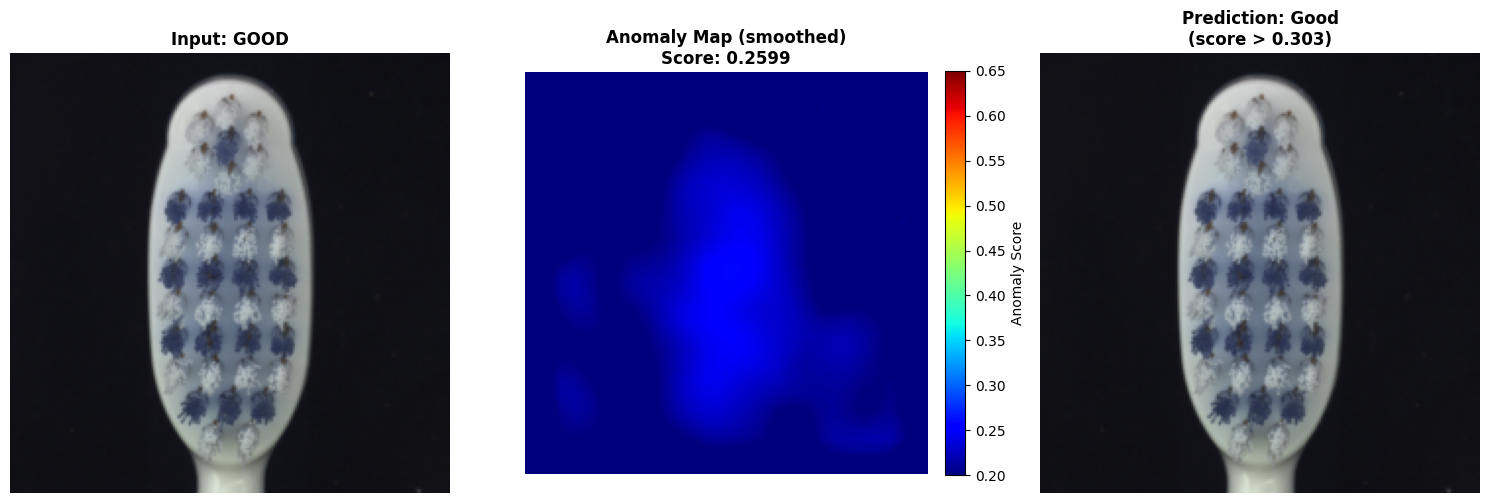

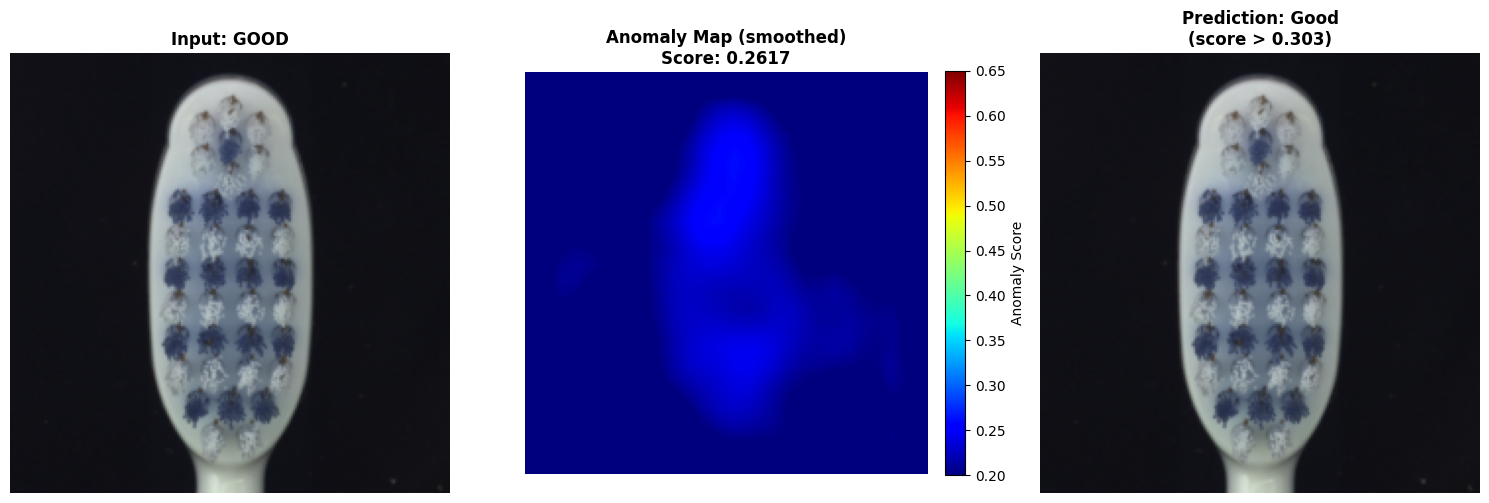

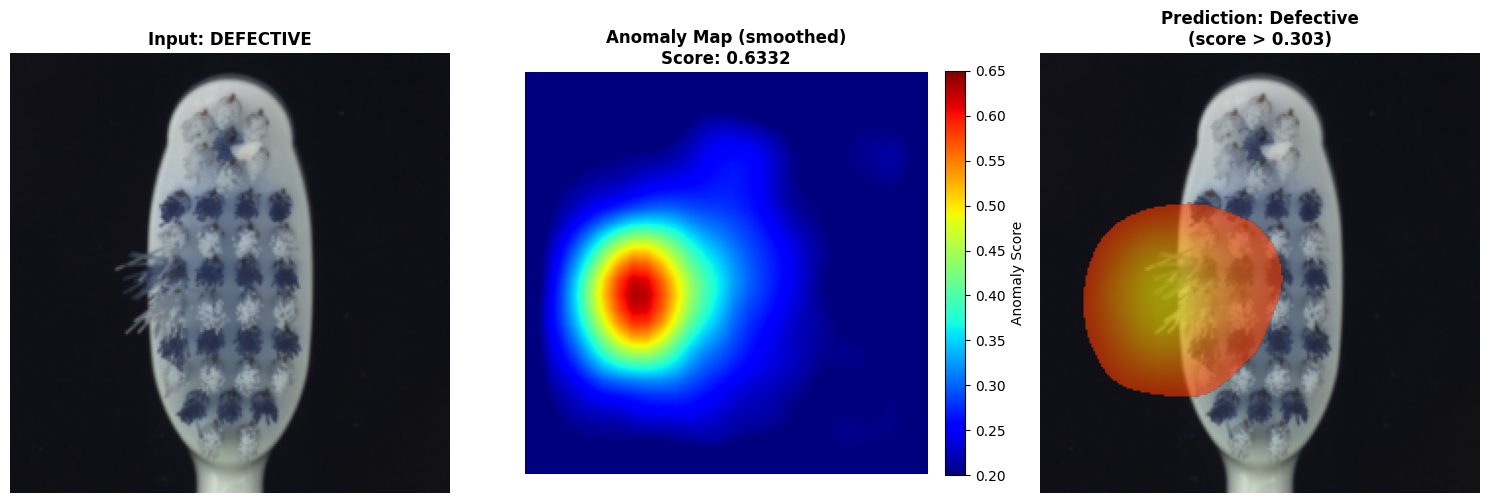

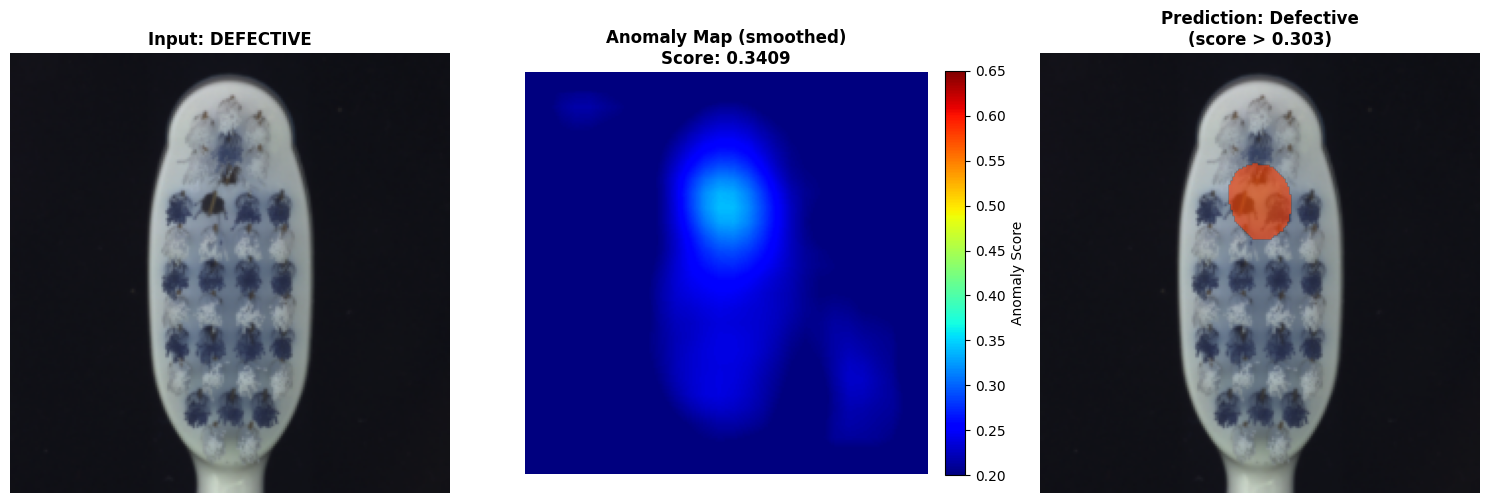

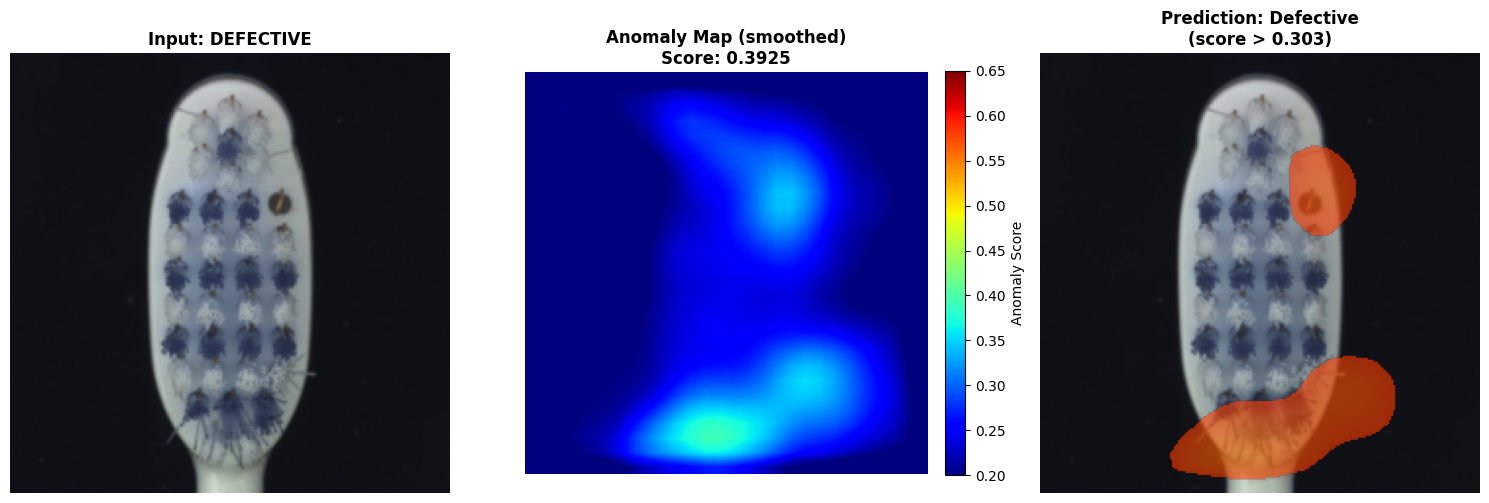

Visualization complete! (6 test images displayed)


In [14]:
config.output_root.mkdir(parents=True, exist_ok=True)

class_labels = ['Good', 'Defective']
score_min, score_max = 0.20, 0.65
imagenet_mean = np.array([0.485, 0.456, 0.406])
imagenet_std = np.array([0.229, 0.224, 0.225])

test_root = config.base_path / config.dataset_name / 'test'
good_files = sorted((test_root / 'good').glob('*.png'))[:3]
defect_files = []
for d in sorted(test_root.iterdir()):
    if d.is_dir() and d.name != 'good':
        defect_files += sorted(d.glob('*.png'))
samples = [(p, 'good') for p in good_files] + [(p, 'defective') for p in defect_files[:3]]

for image_path, class_label in samples:
    image_tensor = image_transform(image_path).to(config.device).unsqueeze(0)
    original_image = image_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    original_image = np.clip(original_image * imagenet_std + imagenet_mean, 0, 1)

    with torch.no_grad():
        features = backbone(image_tensor)
        features_normalized = features / (torch.norm(features, dim=1, keepdim=True) + 1e-8)

    distances = torch.cdist(features_normalized, memory_bank_manager.get(), p=2.0)
    dist_score = torch.min(distances, dim=1)[0]
    anomaly_score = image_anomaly_score(dist_score, method=config.score_method, top_k=config.score_top_k, smooth_sigma=config.smooth_sigma).item()

    side = int(round(dist_score.numel() ** 0.5))
    segm_map = smooth_score_map(dist_score.view(side, side), config.smooth_sigma).view(1, 1, side, side)
    segm_map_upscaled = torch.nn.functional.interpolate(
        segm_map,
        size=(224, 224),
        mode='bilinear'
    ).cpu().squeeze().numpy()

    y_pred = 1 if anomaly_score >= decision_threshold else 0

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(original_image)
    axes[0].set_title(f'Input: {class_label.upper()}', fontsize=12, fontweight='bold')
    axes[0].axis('off')

    im1 = axes[1].imshow(segm_map_upscaled, cmap='jet', vmin=score_min, vmax=score_max)
    axes[1].set_title(f'Anomaly Map (smoothed)\nScore: {anomaly_score:.4f}', fontsize=12, fontweight='bold')
    axes[1].axis('off')
    cbar1 = plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    cbar1.set_label('Anomaly Score', fontsize=10)

    defect_mask = np.ma.masked_where(segm_map_upscaled <= decision_threshold, segm_map_upscaled)
    axes[2].imshow(original_image)
    axes[2].imshow(defect_mask, cmap='autumn', alpha=0.6, vmin=score_min, vmax=score_max)
    axes[2].set_title(f'Prediction: {class_labels[y_pred]}\n(score > {decision_threshold:.3f})', fontsize=12, fontweight='bold')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

print(f"Visualization complete! ({len(samples)} test images displayed)")

---
## ✅ 8. Pipeline Summary
Print a summary of the key properties (leakage-free, normalization, coreset...) and the final results (AUC, F1, threshold).

In [15]:
print("\n" + "="*60)
print("PIPELINE STATUS")
print("="*60)
print(f"\nKey properties:")
print(f"  - Modular code structure (classes in anomaly_system.py)")
print(f"  - No data leakage (threshold from held-out good, not test)")
print(f"  - Feature normalization (L2, consistent on bank and query)")
print(f"  - K-center greedy selection (strategic coreset)")
print(f"  - Threshold calibrated on held-out good (not in memory bank)")
print(f"\nResults:")
print(f"  - AUC-ROC: {auc_roc_score:.4f}")
print(f"  - F1-Score: {f1_test:.4f}")
print(f"  - Memory bank size: {memory_bank_manager.size}")
print(f"  - Decision threshold: {decision_threshold:.4f}")
print(f"\nOutput folder: {config.output_root.absolute()}")
print("="*60)


PIPELINE STATUS

Key properties:
  - Modular code structure (classes in anomaly_system.py)
  - No data leakage (threshold from held-out good, not test)
  - Feature normalization (L2, consistent on bank and query)
  - K-center greedy selection (strategic coreset)
  - Threshold calibrated on held-out good (not in memory bank)

Results:
  - AUC-ROC: 0.9444
  - F1-Score: 0.9355
  - Memory bank size: 3763
  - Decision threshold: 0.3025

Output folder: C:\Users\ADMIN\Desktop\Test\outputs
